In [1]:
import pandas as pd
import json
import matplotlib
matplotlib.rcParams['font.family'] = 'serif' 
matplotlib.rcParams['font.serif'] = ['DejaVu Serif']
import textwrap


In [2]:
METADATA = {}
METADATA["2"] = json.load(open("../2_1/nllf_method/lr_Z_C/pred/llm/w_r_sf/nllf_ef/METADATA.json", "r"))
METADATA["4"] = json.load(open("../4/nllf_method/lr_Z_C/pred/llm/w_r_sf/nllf_ef/METADATA.json", "r"))

BEST_FEATURES = {}
BEST_FEATURES["2"] = pd.read_csv("../2_1/nllf_method/lr_Z_C/pred/llm/w_r_sf/nllf_ef/BEST_FEATURES.csv", index_col=0)
BEST_FEATURES["4"] = pd.read_csv("../4/nllf_method/lr_Z_C/pred/llm/w_r_sf/nllf_ef/BEST_FEATURES.csv", index_col=0)


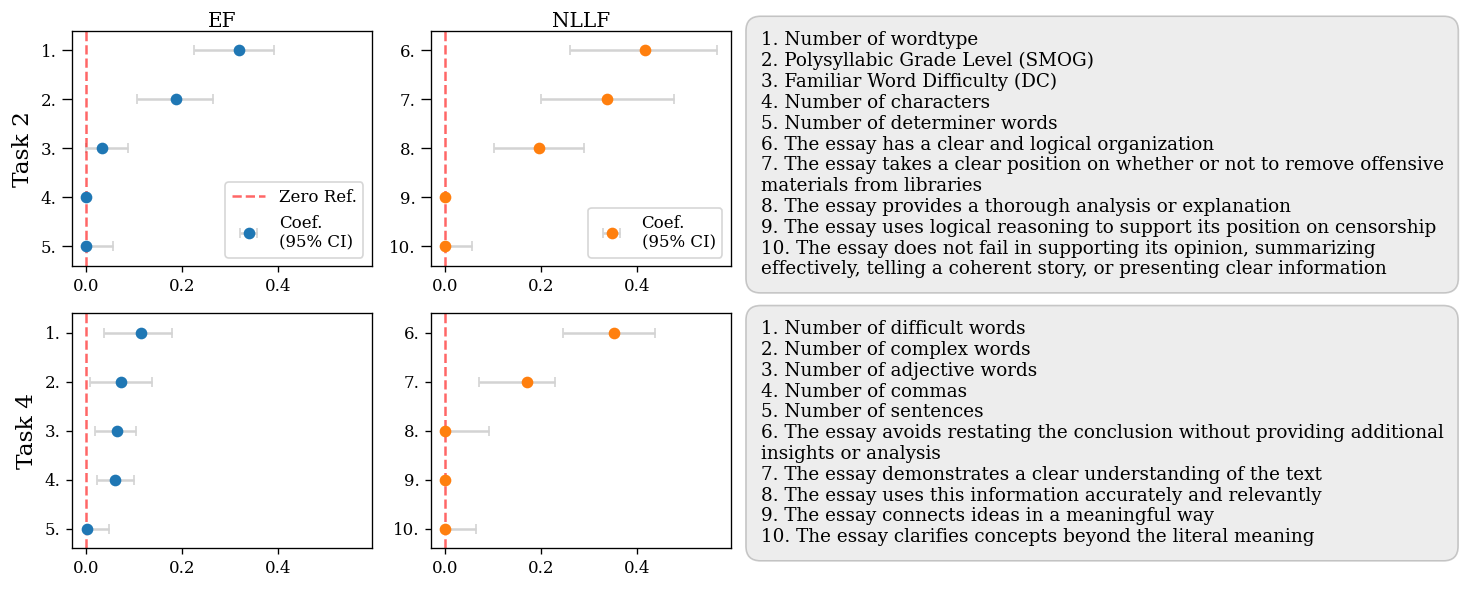

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(2, 4, figsize=(4*3.7, 2*2.8), dpi=120, sharex=False)  # Slightly larger for better readability

dx = 0.3
eps = 0.1

# Share x-axis between the first row of subplots
ax[0, 0].sharex(ax[0, 1])  # Share x-axis between (0,0) and (0,1)
ax[0, 1].sharex(ax[1, 0])
ax[1, 0].sharex(ax[1, 1])

for side in range(2):
    domain_id = ["2", "4"][side]
    significant_features = BEST_FEATURES[domain_id]
    # EF Plot (Top 5)
    mask_ef = significant_features["is_ef"]
    coef_top = significant_features[mask_ef].iloc[:5]["coef"][::-1]
    ci_top_lower = significant_features[mask_ef].iloc[:5]["[0.025"][::-1]
    ci_top_upper = significant_features[mask_ef].iloc[:5]["0.975]"][::-1]

    ax[side, 0].errorbar(coef_top, range(coef_top.shape[0]), 
                xerr=[coef_top - ci_top_lower, ci_top_upper - coef_top], 
                fmt='o', color='tab:blue', ecolor='lightgray', capsize=3, label=f"Coef.\n(95% CI)")

    # NLLF Plot (Top 5)
    mask_nllf = significant_features["is_nllf"]
    coef_bottom = significant_features[mask_nllf].iloc[:5]["coef"][::-1]
    ci_bottom_lower = significant_features[mask_nllf].iloc[:5]["[0.025"][::-1]
    ci_bottom_upper = significant_features[mask_nllf].iloc[:5]["0.975]"][::-1]

    ax[side, 1].errorbar(coef_bottom, range(coef_bottom.shape[0]), 
                xerr=[coef_bottom - ci_bottom_lower, ci_bottom_upper - coef_bottom], 
                fmt='o', color='tab:orange', ecolor='lightgray', capsize=3, label=f"Coef.\n(95% CI)")

    # Add horizontal reference lines at 0 (for both plots)
    ax[side, 0].axvline(x=0, color="red", linestyle="--", alpha=0.6, label="Zero Ref.")
    ax[side, 1].axvline(x=0, color="red", linestyle="--", alpha=0.6)


    # ll_nllf = 5
    # textstr_nllf = lambda ix: f"{ix}" if len(ix.split(' ')) <= ll_nllf else f"{' '.join(ix.split(' ')[:ll_nllf]).strip()}\n{' '.join(ix.split(' ')[ll_nllf:2*ll_nllf]).strip()}" if len(ix.split(' '))<=ll_nllf*2 else f"{' '.join(ix.split(' ')[:ll_nllf]).strip()}\n{' '.join(ix.split(' ')[ll_nllf:2*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[2*ll_nllf:3*ll_nllf]).strip()}" if len(ix.split(' ')) <= 3*ll_nllf else f"{' '.join(ix.split(' ')[:ll_nllf]).strip()}\n{' '.join(ix.split(' ')[ll_nllf:2*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[2*ll_nllf:3*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[3*ll_nllf:4*ll_nllf]).strip()}" if len(ix.split(' ')) <= 4*ll_nllf else f"{' '.join(ix.split(' ')[:ll_nllf]).strip()}\n{' '.join(ix.split(' ')[ll_nllf:2*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[2*ll_nllf:3*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[3*ll_nllf:4*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[4*ll_nllf:5*ll_nllf]).strip()}" if len(ix.split(' ')) <= 6*ll_nllf else f"{' '.join(ix.split(' ')[:ll_nllf]).strip()}\n{' '.join(ix.split(' ')[ll_nllf:2*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[2*ll_nllf:3*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[3*ll_nllf:4*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[4*ll_nllf:5*ll_nllf]).strip()}\n{' '.join(ix.split(' ')[5*ll_nllf:6*ll_nllf]).strip()}"
            
    # ll_ef = 5
    # textstr_ef = lambda ix: f"{ix}" if len(ix.split(' ')) <= ll_ef else f"{' '.join(ix.split(' ')[:ll_ef]).strip()}\n{' '.join(ix.split(' ')[ll_ef:2*ll_ef]).strip()}" if len(ix.split(' '))<=ll_ef*2 else f"{' '.join(ix.split(' ')[:ll_ef]).strip()}\n{' '.join(ix.split(' ')[ll_ef:2*ll_ef]).strip()}\n{' '.join(ix.split(' ')[2*ll_ef:3*ll_ef]).strip()}" if len(ix.split(' ')) <= 3*ll_ef else f"{' '.join(ix.split(' ')[:ll_ef]).strip()}\n{' '.join(ix.split(' ')[ll_ef:2*ll_ef]).strip()}\n{' '.join(ix.split(' ')[2*ll_ef:3*ll_ef]).strip()}\n{' '.join(ix.split(' ')[3*ll_ef:]).strip()}"
            

    text_nllf = [
        textwrap.fill(text, width=70)
        for k, text in enumerate(significant_features[mask_nllf].iloc[:5].index)
    ][::-1]

    text_ef = [
        textwrap.fill(text, width=70)
        for k, text in enumerate(significant_features[mask_ef].iloc[:5].index)
    ][::-1]


    # Set y-axis labels with feature names for both plots
    ax[side, 0].set_yticks(range(coef_top.shape[0]))
    ax[side, 0].set_yticklabels([f"{i}." for i in range(coef_top.shape[0], 0, -1)], fontsize=10)#text_ef, fontsize=9)  # Top 5 features (EF)

    ax[side, 1].set_yticks(range(coef_bottom.shape[0]))
    ax[side, 1].set_yticklabels([f"{i}." for i in range(coef_bottom.shape[0]+coef_top.shape[0], coef_top.shape[0], -1)], fontsize=10)#text_nllf, fontsize=9)  # Last 5 features (NLLF)

    ax[side, 0].set_ylim(-dx-eps, max(coef_top.shape[0], coef_bottom.shape[0])-1+dx+eps)
    ax[side, 1].set_ylim(-dx-eps, max(coef_top.shape[0], coef_bottom.shape[0])-1+dx+eps)

    if side == 0:
        # Set updated titles
        ax[side, 0].set_title("EF", fontsize=12, pad=1)
        ax[side, 1].set_title("NLLF", fontsize=12, pad=1)

    bias = METADATA[domain_id]["bias"]

    # Move the y-ticks to the right
    if side == 0:
        ax[side, 0].tick_params(axis='y', direction='out', length=6, labelright=False, labelleft=True, right=False, left=True)
        ax[side, 1].tick_params(axis='y', direction='out', length=6, labelright=False, labelleft=True, right=False, left=True)
        
        # Add legends
        ax[side, 0].legend(loc="best", fontsize=10)
        
        ax[side, 1].legend(loc="best", fontsize=10)

        features_table = "\n".join([f"{i+1}. {text}" for i, text in enumerate(text_ef[::-1])])+"\n"+"\n".join([f"{i+1+len(text_ef)}. {text}" for i, text in enumerate(text_nllf[::-1])])

        ax[side, 2].text(-0.1, 1, features_table, 
        ha='left', va='top', 
        fontsize=11, color='black',
        bbox=dict(facecolor='lightgray', edgecolor='gray', boxstyle='round,pad=0.8', alpha=0.4),
        transform=ax[side, 2].transAxes)

        # Remove axes for a clean look
        ax[side, 2].set_xticks([])
        ax[side, 2].set_yticks([])
        ax[side, 2].axis('off')
        ax[side, 3].axis('off')

        ax[side, 0].set_ylabel("Task 2", fontsize=14)

    else:
        # ax[2*side+1].tick_params(axis='y', direction='out', length=6, labelright=True, labelleft=False, right=True, left=False)
        # ax[2*side+2].tick_params(axis='y', direction='out', length=6, labelright=True, labelleft=False, right=True, left=False)

        features_table = "\n".join([f"{i+1}. {text}" for i, text in enumerate(text_ef[::-1])])+"\n"+"\n".join([f"{i+1+len(text_ef)}. {text}" for i, text in enumerate(text_nllf[::-1])])

        ax[side, 2].text(-0.1, 0.97, features_table, 
        ha='left', va='top', 
        fontsize=11, color='black',
        bbox=dict(facecolor='lightgray', edgecolor='gray', boxstyle='round,pad=0.8', alpha=0.4),
        transform=ax[side, 2].transAxes)

        # Remove axes for a clean look
        ax[side, 2].set_xticks([])
        ax[side, 2].set_yticks([])
        ax[side, 2].axis('off')
        ax[side, 3].axis('off')

        ax[side, 0].set_ylabel("Task 4", fontsize=14)
        # Add legends

# Set global x-axis label
# fig.text(0.5, -0.03, f"Coefficient Weights with 95% Confidence Interval", ha='center', fontsize=12)

# fig.suptitle("Features with the Highest Coefficients ", ha="center", fontsize=14, y=1.03, x=0.5)

# fig.text(0.5, .96, f"Task 2", ha='center', fontsize=12)#. Bias is {METADATA['2']['bias']:.2f}", ha='center', fontsize=12)
# fig.text(0.5, .96, f"Task 4", ha='center', fontsize=12)#. Bias is {METADATA['4']['bias']:.2f}", ha='center', fontsize=12)

# Adjust layout to prevent overlap
# plt.tight_layout(pad=0, w_pad=0)

# Save the figure
plt.savefig(f"coefficient_analysis.pdf", bbox_inches='tight', transparent=True)

# Show the plot
plt.show()